In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
#ucčitavanje podataka
df = pd.read_csv(
    r"C:\Users\lovro\Desktop\hackatoni\LUMEN_DS.csv",
    sep="|",
    quotechar='"',
    encoding="utf-16",
)

C:\Users\lovro\AppData\Local\Temp\ipykernel_29132\3456964059.py:2: DtypeWarning: Columns (16,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


In [3]:
for i in df.columns:
    if df[i].dtype == "object":
        df[i][df[i].isna()] = "UNKNOWN"

C:\Users\lovro\AppData\Local\Temp\ipykernel_29132\3279061703.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[i][df[i].isna()] = "UNKNOWN"


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1294962 entries, 0 to 1294961
Data columns (total 33 columns):
 #   Column                               Non-Null Count    Dtype  
---  ------                               --------------    -----  
 0   Manufacturing Region                 1294962 non-null  object 
 1   Manufacturing Location Code          1294962 non-null  object 
 2   Intercompany                         1294962 non-null  object 
 3   CustomerID                           1294962 non-null  int64  
 4   Customer industry                    1294962 non-null  object 
 5   Customer Region                      1294962 non-null  object 
 6   Customer First Invoice Date          1294962 non-null  object 
 7   Top Customer Group                   1294962 non-null  object 
 8   Item Code                            1294962 non-null  object 
 9   Product family                       1294962 non-null  object 
 10  Product group                        1294962 non-null  object 
 11

In [5]:
"""
Analyzing one invoice #
zakljucak je da je to jedan racuna s vise linija
isti item moze biti u vise linija
dolje je proucavan odnos cijene i qty i item codea i to nismo nasli povezanost
vecinom cijena za iste iteme bude ista, ponekad bude duplo visa na nekim.
"""

'\nAnalyzing one invoice #\nzakljucak je da je to jedan racuna s vise linija\nisti item moze biti u vise linija\ndolje je proucavan odnos cijene i qty i item codea i to nismo nasli povezanost\nvecinom cijena za iste iteme bude ista, ponekad bude duplo visa na nekim.\n'

In [6]:
inv, count = np.unique(df["Invoice #"], return_counts=True)
sorted_indices = np.argsort(count)[::-1]
inv = inv[sorted_indices]
count = count[sorted_indices]
print(inv, count)  
print(count[count > 1].sum())
print(len(count))


[15968559 15962475 15968138 ... 13987307 13987306 13816515] [318 275 250 ...   1   1   1]
407333
992110


In [28]:
inv, count = np.unique(df["Item Code"], return_counts=True)
print(len(inv))

63020


In [38]:
count[count < 5].sum()

62158

In [7]:
a = df[df["Invoice #"] == inv[1]]
d, c = np.unique(a["Invoice Line #"], return_counts=True)
d1, c1 = np.unique(a["Order Date"], return_counts=True)
d2, c2 = np.unique(a["Item Code"], return_counts=True)  
d3, c3 = np.unique(a["Invoiced price"], return_counts=True) 
d4, c4 = np.unique(a["Invoiced qty (shipped)"], return_counts=True)                  

c = np.sort(c)[::-1]
c1 = np.sort(c1)[::-1]
c2 = np.sort(c2)[::-1]
c3 = np.sort(c3)[::-1]
c4 = np.sort(c4)[::-1]
print(c)
print(c1)
print(c2)
print(c3)
print(c4)

TypeError: '<' not supported between instances of 'int' and 'str'

In [ ]:
b = a.loc[:,["Item Code", "Invoiced price", "Invoiced qty (shipped)"]]
b.sort_values(by=["Item Code"], ascending=False, inplace=True)
np.array(b)

array([['S290-000133', 50.4235, 1.0],
       ['S290-000133', 50.4235, 6.0],
       ['S290-000050', 882.4121, 1.4],
       ['S290-000050', 882.4121, 8.0],
       ['S290-000050', 1764.8242, 3.0],
       ['S290-000050', 1764.8242, 3.0],
       ['S290-000029', 44.8209, 12.0],
       ['S290-000015', 882.4121, 7.0],
       ['S290-000015', 882.4121, 3.0],
       ['S290-000015', 882.4121, 4.2],
       ['S290-000015', 882.4121, 2.0],
       ['S290-000015', 882.4121, 7.0],
       ['S290-000015', 882.4121, 3.0],
       ['S290-000015', 882.4121, 8.0],
       ['S290-000015', 882.4121, 8.0],
       ['S290-000015', 882.4121, 6.0],
       ['S290-000012', 88.2412, 2.0],
       ['S271-000172', 744.6811, 6.0],
       ['S271-000172', 744.6811, 7.0],
       ['S271-000172', 744.6811, 2.0],
       ['S271-000172', 744.6811, 3.0],
       ['S271-000128', 717.6018, 1.4],
       ['S271-000128', 1435.2036, 3.0],
       ['S271-000128', 1435.2036, 3.0],
       ['S271-000121', 128.8602, 1.0],
       ['S271-000091', 7

In [ ]:
""""
analyzing per costumer

"""

In [8]:
people, count = np.unique(df["CustomerID"], return_counts=True)
sorted_indices = np.argsort(count)[::-1]
people = people[sorted_indices]
count = count[sorted_indices]
print(people, count)  
print(count[count > 1].sum())
print(len(count))


[ 19244  18161 224597 ... 107546 107504 216814] [70230 65059 40748 ...     1     1     1]
1292752
12214


{'whiskers': [<matplotlib.lines.Line2D at 0x2170a815d50>,
 'caps': [<matplotlib.lines.Line2D at 0x2170a8170d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x2170a593c50>],
 'medians': [<matplotlib.lines.Line2D at 0x2170a820310>],
 'fliers': [<matplotlib.lines.Line2D at 0x2170a820a50>],
 'means': []}

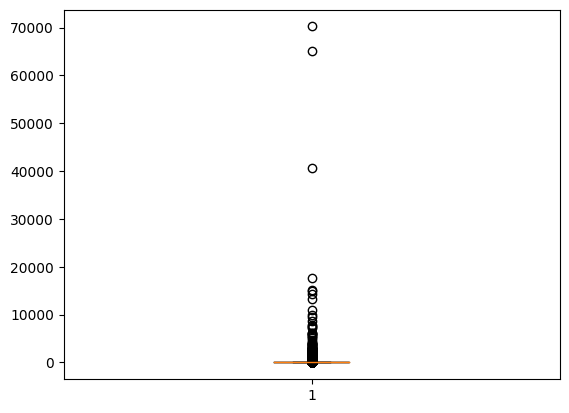

In [12]:
num_invoices_per_customer = []
num_lines_per_customer = []
for customer in people:
    num_invoices = len(df[df["CustomerID"] == customer]["Invoice #"].unique())
    num_invoices_per_customer.append(num_invoices)
    num_lines_per_customer.append(len(df[df["CustomerID"] == customer]))    

plt.boxplot(num_invoices_per_customer)

In [24]:
a = np.array(num_invoices_per_customer)
b = np.array(num_lines_per_customer)
print((b < 10).sum())

7450


In [ ]:
#####
####
#####
#








#####

In [ ]:
" dalje analziramo za jedan item kako se ponsaju varijable za njega"

In [ ]:
item, count = np.unique(df["Item Code"], return_counts=True)
sorted_indices = np.argsort(count)[::-1]
item = item[sorted_indices]
count = count[sorted_indices]
print(item, count)  
print(count[count > 1].sum())
print(len(count))


['BOY485-NPI' '/C' 'TRANSPORTKOSTEN' ... '676077T1' '184829' '663907'] [15916  8356  7947 ...     1     1     1]
1277415
63020


[0.000e+00 7.237e+01 4.000e+01 3.000e+01 9.000e+00 1.724e+00 1.690e-02]
[15909     2     1     1     1     1     1]
[13434  2474     3     3     1     1]
[19245 19261 21441 19244 19557 19478]


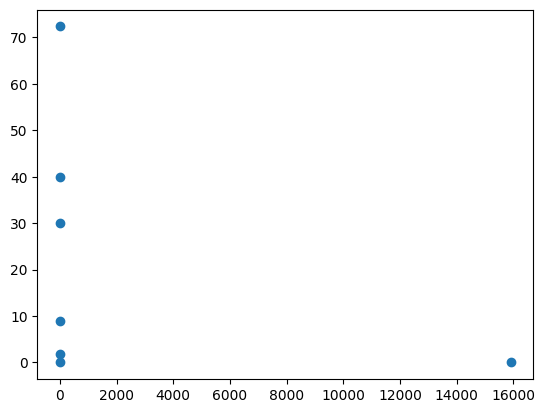

In [ ]:


a = df[df["Item Code"] == item[0]]
d1, c1 = np.unique(a["CustomerID"], return_counts=True)
d3, c3 = np.unique(a["Invoiced price"], return_counts=True) 

sorted_indices = np.argsort(c3)[::-1]
c3 = c3[sorted_indices]
d3 = d3[sorted_indices]
sorted_indices = np.argsort(c1)[::-1]
c1 = c1[sorted_indices]
d1 = d1[sorted_indices] 

print(d3)
print(c3)
plt.scatter(c3,d3)
print(c1)
print(d1)

In [ ]:
costumer, count = np.unique(df["CustomerID"], return_counts=True)
sorted_indices = np.argsort(count)[::-1]
costumer = costumer[sorted_indices]
count = count[sorted_indices]
print(costumer, count)  
print(count[count > 1].sum())
print(len(count))


[ 19244  18161 224597 ... 107546 107504 216814] [70230 65059 40748 ...     1     1     1]
1292752
12214


0
[]
[]


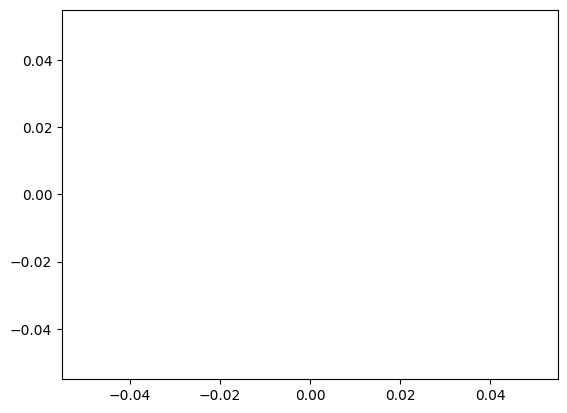

In [ ]:
a = df[df["CustomerID"] == costumer[6]]

item, count = np.unique(df["Item Code"], return_counts=True) ############ nije mu tu dolje jasno zasto je b prazno
sorted_indices = np.argsort(count)[::-1]
item = item[sorted_indices]
count = count[sorted_indices]

print((a["Item Code"] == item[0]).sum())
b = a[a["Item Code"] == item[0]]

d3, c3 = np.unique( b["Invoiced price"], return_counts=True) 

sorted_indices = np.argsort(c3)[::-1]
c3 = c3[sorted_indices]
d3 = d3[sorted_indices]

print(d3)
print(c3)
plt.scatter(c3,d3)

In [ ]:
"""
gledamo kako se product family i product groupovi ponasaju
isti group moze biti u vise familyja

"""

In [ ]:
def analyze_column_relationships(col1, col2):
    # printa u koliko se razlicitih col2 pojavljuje col1
    # vraca listu brojeva koliko se puta se pojavljuje col1 u col2
    temp = np.unique(df[col1])
    lib = {}
    for gr in temp:
        lib[gr] = 0 

    product_families = np.unique(df[col2])

    for product_fam in product_families:
        df_family = df[df[col2] == product_fam]
        product_groups = np.unique(df_family[col1])
        for product_group in product_groups:
            lib[product_group] += 1

    #for key in sorted(lib, key=lib.get):
    #    print(key, lib[key])

    # Descending order (largest to smallest values)
    vals = np.array(list(lib.values()))
    keys = np.array(list(lib.keys()))
    #for key in sorted(lib, key=lib.get, reverse=True):
    #    print(key, lib[key])


    sorted_indices = np.argsort(vals)[::-1]
    sorted_keys = keys[sorted_indices]
    sorted_vals = vals[sorted_indices]
    return  sorted_vals, sorted_keys
            


In [ ]:
analyze_column_relationships("Product family", "Product group")

(array([30, 24,  1,  1,  1,  1]),
 array(['PF002', 'PF001', 'PF000', 'PC016', 'PC010', 'PC001'], dtype='<U5'))

In [ ]:
analyze_column_relationships("Product group", "Product family")

(array([3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]),
 array(['UNKNOWN', 'PC018', 'PC001', 'PC003', 'PC004', 'PC006', 'PC008',
        'PC010', 'PC011', 'PC013', 'SF002', 'PC016', 'PC017', 'PC015',
        'PC019', 'PC023', 'PC028', 'PC020', 'PC025', 'PC026', 'PC022',
        'PC021', 'PC012', 'PC024', 'PC014', 'PC009', 'PC007', 'PC005',
        'PC029', 'PC030', 'PC002', 'SF001', '2020-05-22 00:00:00',
        '2018-09-01 00:00:00', '2016-11-02 00:00:00'], dtype='<U19'))

In [ ]:
counts, keys = analyze_column_relationships("Item Code", "Product group")
print(counts[:40], keys[:40])

[3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 2 2 2
 2 2 2] ['414591' 'ROE-442LG181A200' 'MIC-M1120837' 'ARI-LBL-00852-01'
 'ROE-442LG181A117' 'ROE-442LG181A119' 'GOP-445-26773-D'
 'GOP-445-26773-BD' 'DEL449-C4RWN' 'ROE-442LG181A120' 'SAMPLE'
 'ROE-442LG181A123' 'ROE-442LG181A124' 'ROE-442LG181A131'
 'ROE-442LG181A134' 'ROE-442LG181A135' 'ROE-442LG181A204' '033879'
 'ROE-442LG181A502' 'ROE-442LG181A503' 'ROE-442LG181A504' 'ARI-00506-03'
 'ARI-00499-03' 'ARI-LBL-00636-01' 'GOP-445-16868-C' 'MIC-M1105963-OK'
 'BAL111-232010' '029937' 'NOV-DM-31023092' 'MIC-M1097219' '029903'
 'ZEB-LB-000874-01' 'MIC-M1120838' 'BRI-360-00010-LF' 'INT-H99294-001'
 'DEL449-2265701' 'DEL449-2298701' 'INS-11355-H' 'DEL449-2294801'
 'INS-11569-A']


In [ ]:
counts, keys = analyze_column_relationships("Item Code", "Product family")
print(counts[:40], keys[:40])

[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2] ['358772' '655848' 'GH81-15205A' 'GH81-15039A' 'GH81-14850A' '358771'
 '345621' 'GH81-13891A' 'M125-000007' 'GH81-13867A' 'GH81-13799A'
 'GH81-13702A' 'GH81-13669A' 'M122-000004' 'S108-000004' 'GH81-15388A'
 'GH81-13071A' 'GH81-13031A' '655849' 'GH81-13024A' 'GH81-13008A'
 'GH81-12965A' 'M120-000036' '101625' 'M120-000032' 'M120-000029' '910374'
 'M120-000025' 'GH81-15387A' 'GH81-15405A' 'M120-000006' '655845'
 'S098-000037' 'S098-000038' 'M132-000004' 'M130-000003' 'GH91-00053A'
 'M130-000001' 'S098-000041' 'GH91-00005A']


PC001 1
PC010 1
PC016 1
PF000 1
PF001 24
PF002 30
PF002 30
PF001 24
PC001 1
PC010 1
PC016 1
PF000 1


(1,)


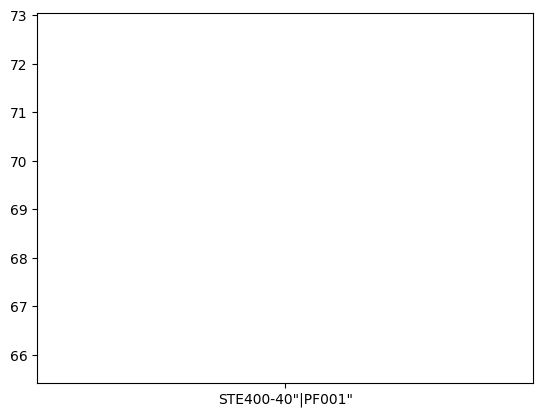

(1,)


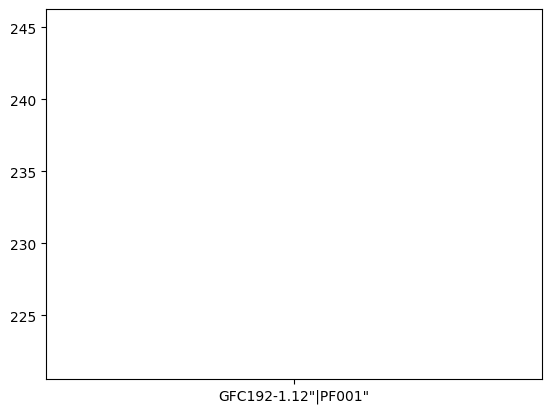

(1,)


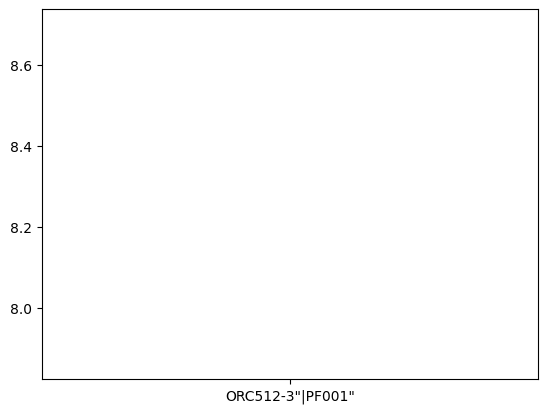

(2602,)


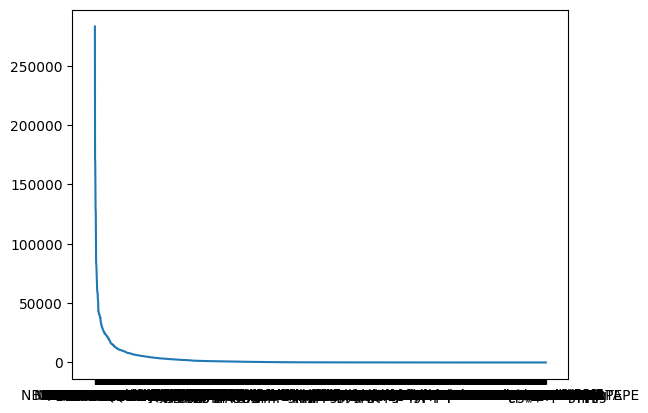

(4009,)


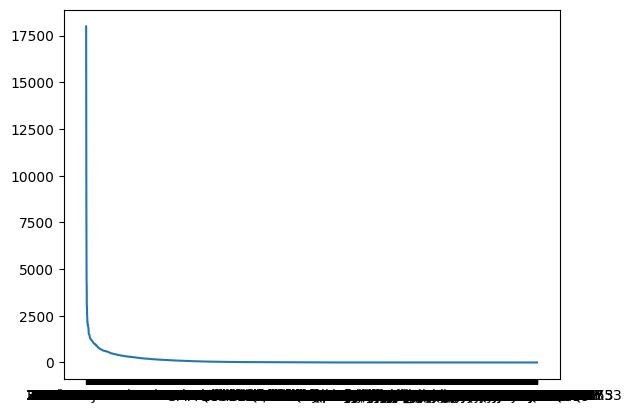

(2,)


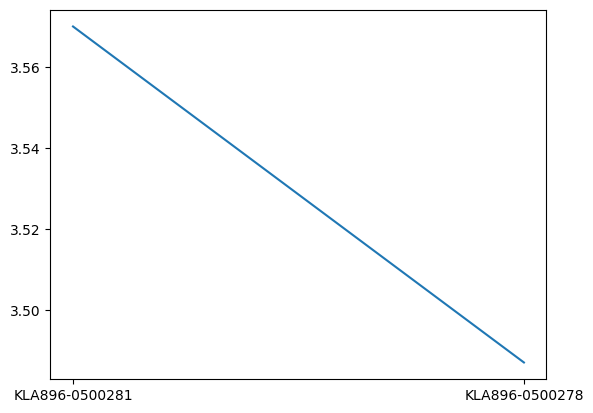

(5,)


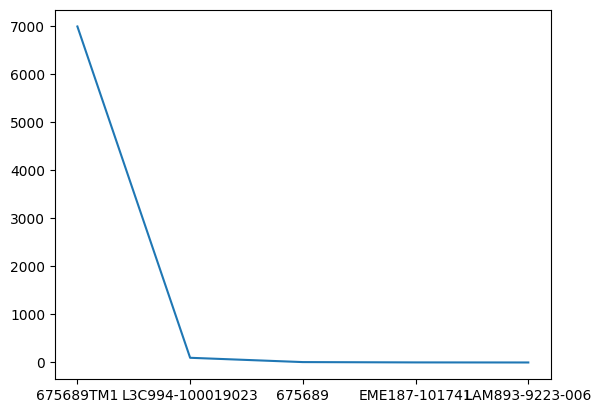

(650,)


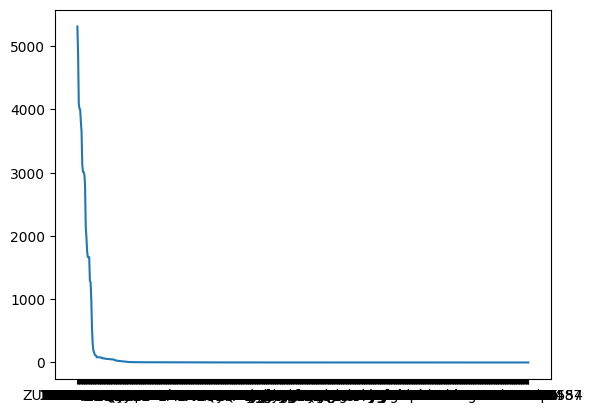

(277,)


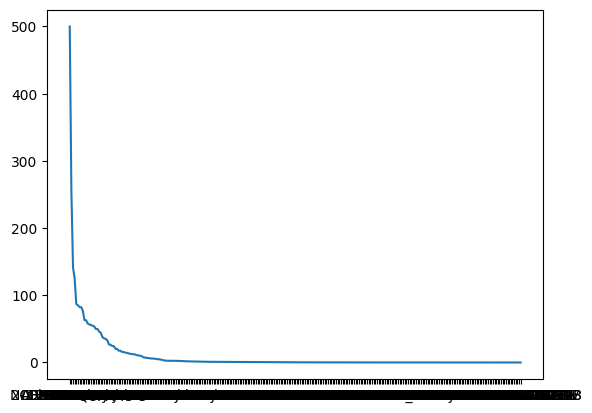

(1413,)


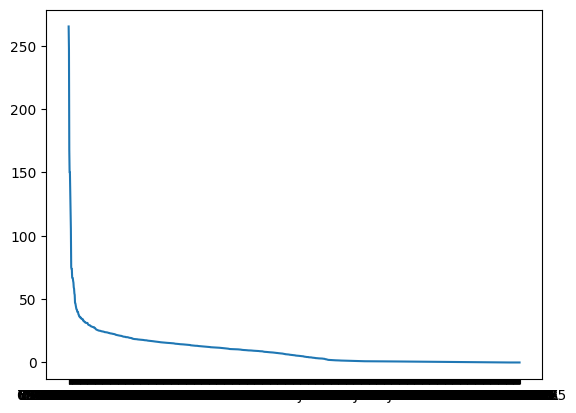

(1490,)


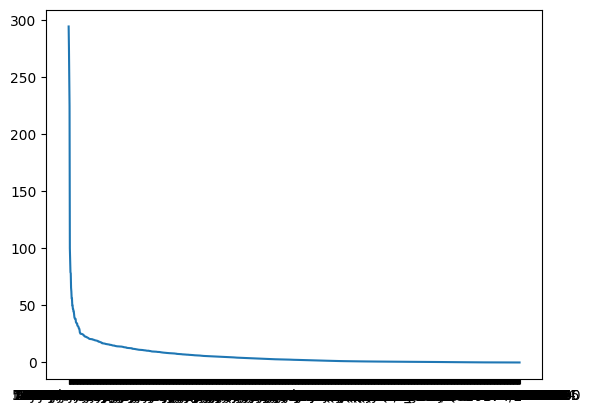

(16102,)


KeyboardInterrupt: 

In [ ]:
# Nested loop: Product Family -> Product Group -> ItemCode (visualize average prices)
import matplotlib.pyplot as plt

product_families = np.unique(df["Product family"])

for product_fam in product_families:
    df_family = df[df["Product family"] == product_fam]
    product_groups = np.unique(df_family["Product group"])
    
    for prod_group in product_groups:
        df_group = df_family[df_family["Product group"] == prod_group]
        
        # Calculate average prices by ItemCode
        avg_prices = df_group.groupby("Item Code")["Invoiced price"].mean().sort_values(ascending=False)
        
        items = np.unique(df_group["Item Code"])
        if(items.shape[0] >= 1):
            print(avg_prices.shape)
            plt.plot(avg_prices)
            plt.show()


Series([], Name: Invoice Line #, dtype: object)

In [ ]:
a = df[df["Invoice #"] == inv[1]]
d, c = np.unique(a["Invoice Line #"], return_counts=True)
d1, c1 = np.unique(a["Order Date"], return_counts=True)
d2, c2 = np.unique(a["Item Code"], return_counts=True)                   
c = np.sort(c)[::-1]
c1 = np.sort(c1)[::-1]
c2 = np.sort(c2)[::-1]
print(c)
print(c1)
print(c2)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
[275]
[13 10  9  9  8  7  6  6  6  6  6  5  5  5  5  4  4  4  4  4  4  4  4  4
  3  3  3  3  3  3  3  3  3  3  3  3  3  3  2  2  2  2  2  2  2  2  2  2
  2  2  2  2  2  2  2  2  2  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1]


In [ ]:
a,c = np.unique(df["Invoice Line "], return_counts=True)
sorted_indices = np.argsort(c)[::-1]
a = a[sorted_indices]  
c = c[sorted_indices]
print(a,c)

TypeError: '<' not supported between instances of 'int' and 'str'

In [ ]:
for data in df["Invoice Line #"]:
    if not isinstance(data, int):
        print(data)

18625702
18694361
18540853
18583304
18625948
18688813
18596464
18653787
18671274
18691574
12894042
14400910
14401082
12987369
12994621
12997386
12998687
13002612
13015039
13014892
13024756
13027577
6552012
13036240
18535485
18535182
18534498
18534211
18534165
18533726
18533456
18533558
18533557
18533016
18532388
18532919
18532918
18532575
18531740
18531739
18531891
18531876
18531596
18575778
18575217
18575127
18574522
18574552
18574750
18573566
18574066
18574053
18572906
18572873
18572279
18572179
18571578
6061734
6098643
6061825
6098644
6125556
6057053
27588731
27584311
27587229
27586440
27593854
27591887
6064388
27584912
27592388
27591662
27591481
6060652
27574246
27572390
27573459
6103879
6054536
27572008
6124375
6103388
6125861
6125453
6105076
27582516
6129824
27587257
27582839
6067865
27593885
5986142
5776586
5990093
5999571
5968787
5993824
5870463
5959656
5967836
2952673
17546714
14731680
6930508
6930703
6930813
6933864
6934175
6935299
6936191
6936170
6936036
6886278
6947746
6948

In [ ]:
product_family = np.unique("Product family")
for product_fam in product_family:
    df_temp = df[df["Product family"] == product_fam]
    product_group = np.unique(df_temp["Product group"])
    for prod_g in product_group:
         

In [ ]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    sparse_output=False,  # Set to True for memory efficiency with many categories
    handle_unknown='ignore',  # Handle unseen categories in test data
)

encoded_array = encoder.fit_transform(df[['Manufacturing Region']])

# Get feature names
feature_names = np.array([f'Manufacturing Region_{i}' for i,cat in enumerate(encoder.categories_[0])])

# Convert to DataFrame
df_encoded = pd.DataFrame(
    encoded_array,
    columns=feature_names,
    index=df.index
)

# Combine with original numerical columns
numerical_cols = df.select_dtypes(include=['number']).columns
df_final = pd.concat([df[numerical_cols], df_encoded], axis=1)


In [ ]:
people = df_final["CustomerID"].unique()
person = people[0]
person_data = df_final[df_final["CustomerID"] == person].copy()

df_final = df.copy()

for i in range(len(feature_names)):


In [ ]:
for column in categorical_cols:
    encoder = OneHotEncoder(
        sparse_output=False,  # Set to True for memory efficiency with many categories
        handle_unknown='ignore',  # Handle unseen categories in test data
    )

    encoded_array = encoder.fit_transform(df[[column]])

    # Get feature names
    feature_names = np.array([f'{column}_{i}' for i,cat in enumerate(encoder.categories_[0])])

    # Convert to DataFrame
    df_encoded = pd.DataFrame(
        encoded_array,
        columns=feature_names,
        index=df.index
    )
    df_final = pd.concat([df_final, df_encoded], axis=1)




[0.67590618336887, 0.0, 0.32409381663113007, 0.0]

In [ ]:
df_final.columns

Index(['CustomerID', 'Invoice #', 'Order #', 'Order Line #',
       'Invoiced qty (shipped)', 'Ordered qty', 'Invoiced price',
       'Invoiced price (TX)', 'Cost of part', 'Material cost of part',
       'Labor cost of part', 'Overhead cost of part', 'GM%',
       '# of unique products on a quote', 'Manufacturing Region_0',
       'Manufacturing Region_1', 'Manufacturing Region_2',
       'Manufacturing Region_3'],
      dtype='object')

In [ ]:
for i in df.columns:
    if df[i].dtype == "object":
        df[i][df[i].isna()] = "UNKNOWN"

C:\Users\lovro\AppData\Local\Temp\ipykernel_16820\3279061703.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[i][df[i].isna()] = "UNKNOWN"


In [ ]:
a,c  = np.unique(df["Customer industry"], return_counts=True)
a1,c1  = np.unique(df["Customer Region"], return_counts=True)

In [ ]:
print(a)
print(c)

['IC000' 'IC001' 'IC002' 'IC003' 'IC004' 'IC005' 'IC006' 'IC007' 'IC008'
 'IC009' 'IC010' 'IC011' 'IC012' 'IC013' 'IS0047']
[453233  23045  28634 103123  64220  96904  11743 183975 175248  37024
  49535  59069   9151     29     29]


In [ ]:
people = df["CustomerID"].unique()
person_data = df[df["CustomerID"] == person].copy() 
person_data["Top Customer Group"].values[0]

'OTHER'

In [ ]:
other, star = 0, 0
people = df["CustomerID"].unique()
for i, person in enumerate(people): # iteriramo po svim ljudima
    person_data = df[df["CustomerID"] == person].copy() 
    
    if person_data.shape[0] >0 and person_data["Top Customer Group"].values[0] == "STAR":
        star += 1
    else:
        other += 1
print(f"STAR: {star}, OTHER: {other}")

STAR: 87, OTHER: 12127


In [ ]:
# from numpy import NaN

# df['Order Date_temp'] = pd.to_datetime(df['Order Date'], errors='coerce')

# valid_date_rows = df[~df['Order Date_temp'].isna()]

# min_total = valid_date_rows["Order Date_temp"].min()


# people = df["CustomerID"].unique()

# data_points = np.zeros((people.shape[0], 10))


# for i, person in enumerate(people):
    
#     n = 0
#     while n == 0 :
#         person_data = df[df["CustomerID"] == person]
#         n = person_data.shape[0]

#     person_data['Order Date_temp'] = pd.to_datetime(person_data['Order Date'], errors='coerce')

#     invalid_date_rows = person_data[person_data['Order Date_temp'].isna()]
#     m = len(invalid_date_rows)
#     n = person_data.shape[0]

#     if m == 0:
#         min,max = person_data["Order Date"].min(), person_data["Order Date"].max()
#         date1 = pd.to_datetime(min)
#         date2 = pd.to_datetime(max)
#         days_diff = (date2 - date1).days
#         last_order = (date1 - min_total).days
#     else:
#         days_diff = NaN
#         last_order = NaN


#     avg_price = person_data["Invoiced price"].mean()
#     avg_count_ordered = person_data["Ordered qty"].mean()
#     avg_count_delivered = person_data["Invoiced qty (shipped)"].mean()

#     corr_price_ordered = person_data["Invoiced price"].corr(person_data["Ordered qty"])
#     corr_price_delivered = person_data["Invoiced price"].corr(person_data["Invoiced qty (shipped)"])
#     corr_qty = person_data["Ordered qty"].corr(person_data["Invoiced qty (shipped)"])

#     gm = person_data["GM%"].mean()
#     data_points[i] = [days_diff, last_order, n, avg_price, avg_count_ordered, avg_count_delivered,
#                       corr_price_ordered, corr_price_delivered, corr_qty, gm]               

In [ ]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler



def remove_outliers_iqr(df, columns=None, multiplier=1.5):
    """
    uklanja retke koji imaju outlier prema IQR metodi
    gledaju se outlieri po stupcima columns
    """
    if columns is None:
        columns = df.columns
    
    df_clean = df.copy()
    outliers_mask = pd.Series(False, index=df.index)
    
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - multiplier * IQR
        upper_bound = Q3 + multiplier * IQR
        
        col_outliers = (df[col] < lower_bound) | (df[col] > upper_bound)
        outliers_mask = outliers_mask | col_outliers
        
        print(f"{col}: {col_outliers.sum()} outliers ({col_outliers.sum()/len(df)*100:.1f}%)")
    
    print(f"\nTotal rows before removal: {len(df)}")
    print(f"Total outliers: {outliers_mask.sum()} ({outliers_mask.sum()/len(df)*100:.1f}%)")
    
    df_clean = df[~outliers_mask]
    print(f"Total rows after removal: {len(df_clean)}")
    
    return df_clean, outliers_mask


In [ ]:
#ovdje gledamo koliko svaki covjek/kompanija je napravio narudžbi i po toj mjeri micemo outliere, njih je 1%, njih posebno hendlat

n_orders_per_customer = df.groupby('CustomerID').size().reset_index(name='n_orders')
high_volume_threshold = n_orders_per_customer['n_orders'].quantile(0.99)  # Top 1%
high_volume_customers = n_orders_per_customer[
    n_orders_per_customer['n_orders'] > high_volume_threshold
]['CustomerID'].tolist()

print(f"High-volume customers (>{high_volume_threshold:.0f} orders): {len(high_volume_customers)} ({len(high_volume_customers)/len(n_orders_per_customer)*100:.1f}%)")

# Separate them
df_high_volume = df[df['CustomerID'].isin(high_volume_customers)]
df_regular = df[~df['CustomerID'].isin(high_volume_customers)]

High-volume customers (>1680 orders): 123 (1.0%)


In [ ]:
import numpy as np
import pandas as pd
from numpy import NaN
from sklearn.impute import SimpleImputer

def imputing(df):
    """
    vraca data points dta frame i np  array
    svaki redak je 10 mjera koje se izračunaju za neku osobu 
    mogli bismo i neke druge mjere, ove sam ja tako, po svojoj procjeni stavio, koje su mi se činile bitne

    """
    df['Order Date_temp'] = pd.to_datetime(df['Order Date'], errors='coerce')

    valid_date_rows = df[~df['Order Date_temp'].isna()]

    min_total = valid_date_rows["Order Date_temp"].min() # tu dobijemo najstariju kupovinu ukupno


    people = df["CustomerID"].unique()
    print(f"Total unique customers: {len(people)}")
    data_points = np.zeros((people.shape[0], 10))

    for i, person in enumerate(people): # iteriramo po svim ljudima
        
        
        person_data = df[df["CustomerID"] == person].copy()  
        
        n = person_data.shape[0]
        
        person_data['Order Date_temp'] = pd.to_datetime(person_data['Order Date'], errors='coerce')
        
        # gledamo datuma koji nisu ispravno upisani ili nedostaju
        invalid_date_rows = person_data[person_data['Order Date_temp'].isna()]
        m = len(invalid_date_rows)
        

        # u ovom bloku racunamo učestalost(frequency) kupovine, i posljednji put kada je osoba kupovala
        if m == 0 and n > 0:  
            try:
                min_date = person_data["Order Date_temp"].min()
                max_date = person_data["Order Date_temp"].max()
                
                if pd.notna(min_date) and pd.notna(max_date):
                    days_diff = (max_date - min_date).days
                    last_order = (min_date - min_total).days
                else:
                    days_diff = np.nan
                    last_order = np.nan
            except:
                days_diff = np.nan
                last_order = np.nan
        else:
            days_diff = np.nan
            last_order = np.nan
        
        
        #računamo prosječnu cijenu, brojnaručenih predmeta i broj dostavljenih predmeta
        avg_price = person_data["Invoiced price"].mean(skipna=True)
        avg_count_ordered = person_data["Ordered qty"].mean(skipna=True)
        avg_count_delivered = person_data["Invoiced qty (shipped)"].mean(skipna=True)
        
        #blok računa korelaciju broja naručenih podataka i cijene
        valid_pairs_price_ordered = person_data[["Invoiced price", "Ordered qty"]].dropna().shape[0]
        if valid_pairs_price_ordered >= 3:  # zahtjevamo barem tri podatka za korelaciju
            corr_price_ordered = person_data["Invoiced price"].corr(person_data["Ordered qty"])
        else:
            corr_price_ordered = np.nan
        
        
        #blok računa korelaciju broja dostavljenih podataka i cijene
        valid_pairs_price_delivered = person_data[["Invoiced price", "Invoiced qty (shipped)"]].dropna().shape[0]
        if valid_pairs_price_delivered >= 3:  # zahtjevamo barem tri podatka za korelaciju
            corr_price_delivered = person_data["Invoiced price"].corr(person_data["Invoiced qty (shipped)"])
        else:
            corr_price_delivered = np.nan
        
        
        #blok računa korelaciju broja naručenih podataka i broja dostavljenih
        valid_pairs_qty = person_data[["Ordered qty", "Invoiced qty (shipped)"]].dropna().shape[0]
        if valid_pairs_qty >= 3:  # zahtjevamo barem tri podatka za korelaciju
            corr_qty = person_data["Ordered qty"].corr(person_data["Invoiced qty (shipped)"])
        else:
            corr_qty = np.nan
        
        
        #sprema gm% to je u biti zarada: (prodajna cijena-cijena)/prodajna cijena 
        gm_data = person_data["GM%"].dropna()
        if len(gm_data) >= 3:
            gm = gm_data.mean()
        else:
            gm = np.nan
        
        # popuniti sve s nan
        data_points[i] = [days_diff if not pd.isna(days_diff) else np.nan,
                        last_order if not pd.isna(last_order) else np.nan,
                        n,
                        avg_price if not pd.isna(avg_price) else np.nan,
                        avg_count_ordered if not pd.isna(avg_count_ordered) else np.nan,
                        avg_count_delivered if not pd.isna(avg_count_delivered) else np.nan,
                        corr_price_ordered,  # Already handled NaN
                        corr_price_delivered,  # Already handled NaN
                        corr_qty,  # Already handled NaN
                        gm if not pd.isna(gm) else np.nan]

    # After building data_points, impute remaining NaNs with median
    print(f"NaN counts before imputation:")
    print(pd.DataFrame(data_points).isna().sum())

    # median imputer
    imputer = SimpleImputer(strategy='median')
    data_points_imputed = imputer.fit_transform(data_points)

    print(f"\nNaN counts after imputation:")
    print(pd.DataFrame(data_points_imputed).isna().sum())

    # genreira dataframe od podatka
    column_names = ['days_diff', 'last_order', 'n_orders', 'avg_price', 
                    'avg_ordered_qty', 'avg_delivered_qty',
                    'corr_price_ordered', 'corr_price_delivered', 
                    'corr_qty', 'gm']

    data_points_imputed_df = pd.DataFrame(data_points_imputed, columns=column_names)

    return data_points_imputed_df, data_points_imputed
# Example of running k-means on the imputed data:
# from sklearn.cluster import KMeans
# kmeans = KMeans(n_clusters=3, random_state=42)
# clusters = kmeans.fit_predict(data_points_imputed)

In [ ]:
a = np.unique(df_regular['CustomerID'])
a.shape

(12091,)

In [ ]:
data_points_imputed_df, data_points_imputed = imputing(df_regular)       

C:\Users\lovro\AppData\Local\Temp\ipykernel_23792\3627917599.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Order Date_temp'] = pd.to_datetime(df['Order Date'], errors='coerce')


Total unique customers: 12091
NaN counts before imputation:
0    1576
1    1576
2       0
3       5
4      74
5       0
6    5010
7    4806
8    4633
9    4263
dtype: int64

NaN counts after imputation:
0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
9    0
dtype: int64


(12091, 10)

In [ ]:

# Remove outliers
columns_for_outlier_removal = ['avg_price', 'avg_ordered_qty', 'avg_delivered_qty', 
                                'days_diff', 'gm']  # Choose relevant columns


# ovaj dio makne pola podataka
#df_clean, outlier_mask = remove_outliers_iqr(data_points_imputed_df, columns_for_outlier_removal)


In [ ]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_points_imputed_df)



KMeans(n_clusters=10, n_init=10, random_state=42)

In [ ]:
k = 2 
min_size = 100

N = data_scaled.shape[0]


# Track original indices
active_idx = np.arange(N)
removed_idx = np.array([], dtype=int)

while True:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(data_scaled[active_idx])
    
    labels = kmeans.labels_
    unique, counts = np.unique(labels, return_counts=True)
    
    small_clusters = unique[counts < min_size]
    
    if len(small_clusters) == 0:
        break
    
    mask_small = np.isin(labels, small_clusters)
    
    # Move small cluster indices to removed
    removed_idx = np.concatenate([removed_idx, active_idx[mask_small]])
    
    # Keep only large clusters
    active_idx = active_idx[~mask_small]

# Final clustering on surviving points
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
kmeans.fit(data_scaled[active_idx])

final_labels_active = kmeans.labels_

# Assign removed points to nearest centroid
if len(removed_idx) == 0:
    final_labels = np.empty(N, dtype=int)
    final_labels[active_idx] = final_labels_active
else:
    removed_points = data_scaled[removed_idx]
    distances = kmeans.transform(removed_points)
    final_labels_removed = np.argmin(distances, axis=1)

    # Construct final label array
    final_labels = np.empty(N, dtype=int)
    final_labels[active_idx] = final_labels_active
    final_labels[removed_idx] = final_labels_removed


In [ ]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score as sklearn_silhouette_score
from sklearn.preprocessing import StandardScaler

# Scale
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_points_imputed_df)
min_size = 100

def adjusted_kmeans(data_scaled, k, min_size=100):
    N = data_scaled.shape[0]


    # Track original indices
    active_idx = np.arange(N)
    removed_idx = np.array([], dtype=int)

    while True:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(data_scaled[active_idx])
        
        labels = kmeans.labels_
        unique, counts = np.unique(labels, return_counts=True)
        
        small_clusters = unique[counts < min_size]
        
        if len(small_clusters) == 0:
            break
        
        mask_small = np.isin(labels, small_clusters)
        
        # Move small cluster indices to removed
        removed_idx = np.concatenate([removed_idx, active_idx[mask_small]])
        
        # Keep only large clusters
        active_idx = active_idx[~mask_small]

    # Final clustering on surviving points
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(data_scaled[active_idx])

    final_labels_active = kmeans.labels_

    # Assign removed points to nearest centroid
    if len(removed_idx) == 0:
        final_labels = np.empty(N, dtype=int)
        final_labels[active_idx] = final_labels_active
    else:
        removed_points = data_scaled[removed_idx]
        distances = kmeans.transform(removed_points)
        final_labels_removed = np.argmin(distances, axis=1)

        # Construct final label array
        final_labels = np.empty(N, dtype=int)
        final_labels[active_idx] = final_labels_active
        final_labels[removed_idx] = final_labels_removed

    return final_labels, active_idx, removed_idx

In [ ]:
import numpy as np

def metrics(data_points, labels):
    k = labels.max() + 1
    
    # Compute centroids
    centroids = np.vstack([
        data_points[labels == i].mean(axis=0)
        for i in range(k)
    ])
    
    # Silhouette
    silhouette = sklearn_silhouette_score(data_points, labels)
    
    # Mean distance to assigned centroid
    mean_centroid_distance = np.mean(
        np.linalg.norm(data_points - centroids[labels], axis=1)
    )
    
    return silhouette, mean_centroid_distance

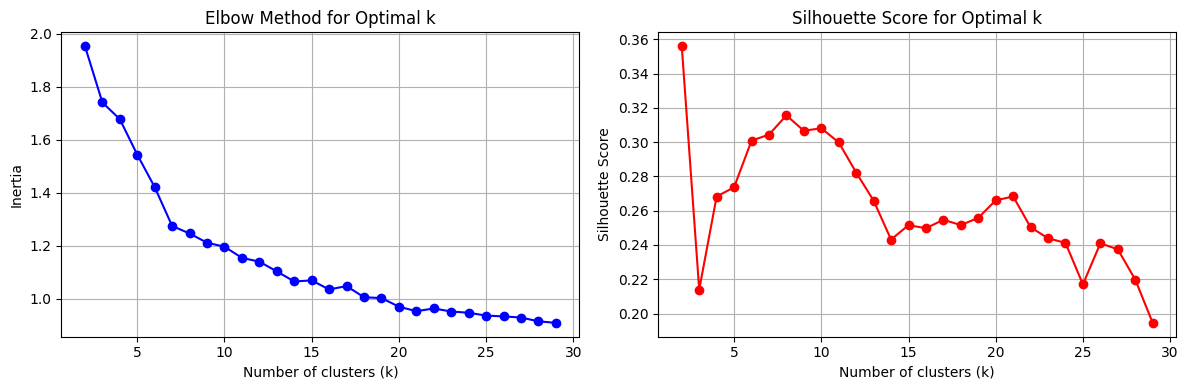

k=2: Silhouette Score = 0.3560
k=3: Silhouette Score = 0.2140
k=4: Silhouette Score = 0.2683
k=5: Silhouette Score = 0.2736
k=6: Silhouette Score = 0.3008
k=7: Silhouette Score = 0.3043
k=8: Silhouette Score = 0.3156
k=9: Silhouette Score = 0.3066
k=10: Silhouette Score = 0.3081
k=11: Silhouette Score = 0.2998
k=12: Silhouette Score = 0.2822
k=13: Silhouette Score = 0.2658
k=14: Silhouette Score = 0.2432
k=15: Silhouette Score = 0.2515
k=16: Silhouette Score = 0.2498
k=17: Silhouette Score = 0.2547
k=18: Silhouette Score = 0.2516
k=19: Silhouette Score = 0.2558
k=20: Silhouette Score = 0.2660
k=21: Silhouette Score = 0.2683
k=22: Silhouette Score = 0.2503
k=23: Silhouette Score = 0.2439
k=24: Silhouette Score = 0.2412
k=25: Silhouette Score = 0.2170
k=26: Silhouette Score = 0.2410
k=27: Silhouette Score = 0.2374
k=28: Silhouette Score = 0.2198
k=29: Silhouette Score = 0.1945


In [ ]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

"""
 tu se računa klasični k means i silouhette score(to nisam ziher kaj je to je chat dao) 
 za raličit broj clustera da se odredi optimalni k
"""

column_names = ['days_diff', 'last_order', 'n_orders', 'avg_price', 
                'avg_ordered_qty', 'avg_delivered_qty',
                'corr_price_ordered', 'corr_price_delivered', 
                'corr_qty', 'gm']


# 2. Scale the data (crucial for k-means!)
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_points_imputed_df)

# 3. Find optimal number of clusters using elbow method
inertias = []
silhouette_scores = []
K_range = range(2, 30)

for k in K_range:
    """
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(data_scaled)
    silhouette_score, inertia = metrics(data_scaled, kmeans.labels_)
    """
    #ovo je adjusted k means koji uvijek daje clustere koji imaju barem 100 članova
    final_labels, active_idx, removed_idx = adjusted_kmeans(data_scaled,k, min_size=100)
    silhouette_score, inertia = metrics(data_scaled, final_labels)
    
    inertias.append(inertia)
    silhouette_scores.append(silhouette_score)

# Plot elbow curve
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Elbow method plot
axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method for Optimal k')
axes[0].grid(True)

# Silhouette score plot
axes[1].plot(K_range, silhouette_scores, 'ro-')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score for Optimal k')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Print silhouette scores
for k, score in zip(K_range, silhouette_scores):
    print(f"k={k}: Silhouette Score = {score:.4f}")

# 4. Choose optimal k (let's say based on silhouette score)


In [ ]:
data_scaled.shape

(12091, 10)

In [ ]:
cluster_labels, active_idx, removed_idx = adjusted_kmeans(data_scaled, 7, min_size=100)
np.unique(cluster_labels)

array([0, 1, 2, 3, 4, 5, 6])


Optimal number of clusters: 8
(12091, 10)

=== Cluster Analysis ===

Cluster sizes:
0    1733
1    2241
2     820
3    2324
4     321
5     993
6     163
7    3496
Name: Cluster, dtype: int64

Cluster means (scaled back to original units):
          days_diff   last_order    n_orders    avg_price  avg_ordered_qty  \
Cluster                                                                      
0        432.811887  6922.372764   11.836699   314.511642     3.190834e+03   
1        819.275324  6744.863454   71.493083   589.131245     6.539947e+03   
2        433.268293  6930.054878   16.242683   435.836308     4.717030e+03   
3         43.495267  7430.729346    5.876076   985.959262     1.974106e+03   
4        971.342679  6653.713396  824.383178  2772.700911     2.582696e+05   
5        542.944612  6857.770393   56.741188   320.895534     1.585811e+04   
6        489.564417  6843.030675   85.190184    85.422627     1.082198e+06   
7        167.706236  6910.082094   10.357551   789.509009

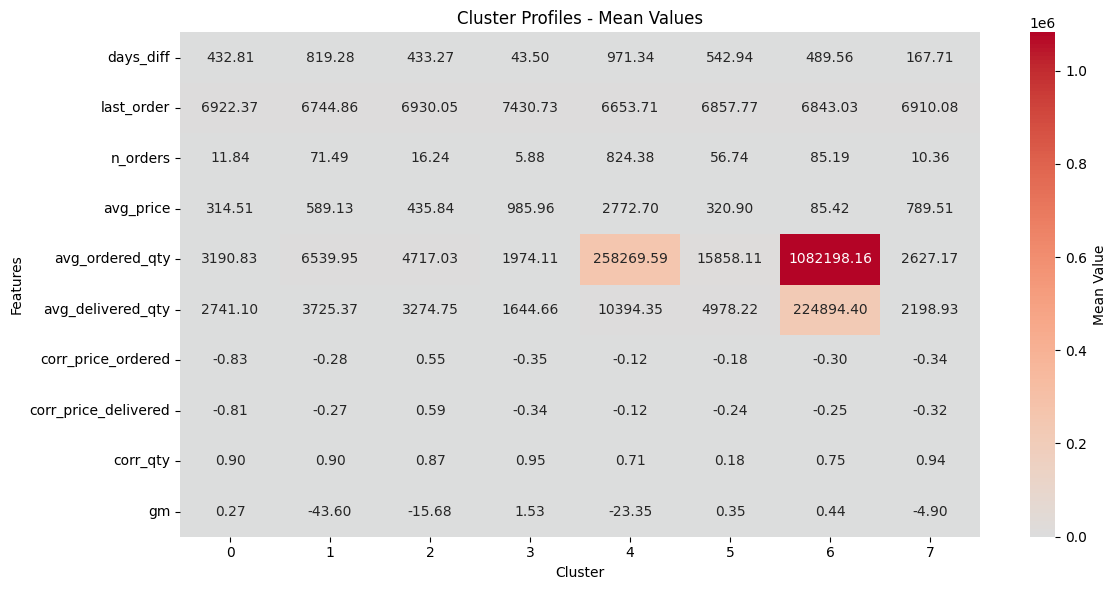

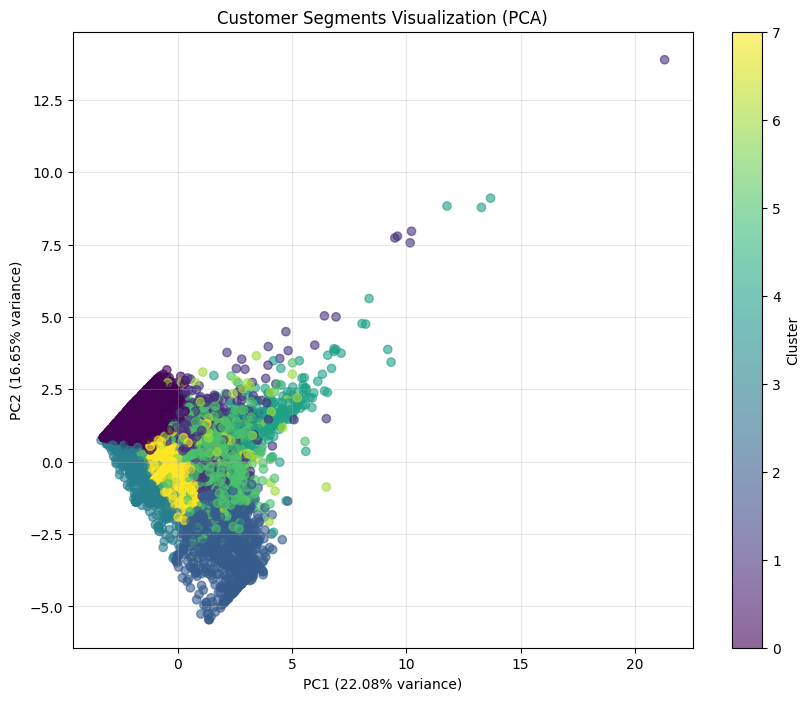


Cluster Centers (original units):
    days_diff   last_order    n_orders    avg_price  avg_ordered_qty  \
0   85.461796  7164.804324    6.112188   888.034177     2.476935e+03   
1  671.826502  6794.748110  171.871866   724.854569     3.015141e+04   
2  837.500000  6797.000000  295.250000     4.189625     4.792849e+07   
3  572.526266  6828.287854   26.826242   452.396802     7.630228e+03   
4  611.000000  6703.000000   20.000000  6779.501500     2.650000e+00   

   avg_delivered_qty  corr_price_ordered  corr_price_delivered  corr_qty  \
0        2177.537031           -0.354315             -0.332711  0.948072   
1       13802.795445            0.131367              0.112119  0.634266   
2       16032.308925           -0.199129             -0.330978  0.356920   
3        6131.768889           -0.549817             -0.534938  0.857692   
4           1.800000           -0.258198             -0.151291  0.888082   

             gm  
0      0.886518  
1     -8.248282  
2      0.331264  
3  

In [ ]:
# odabrao sam 11 tu sad dalje ide neka analiza i vizualizacija
optimal_k = 8
print(f"\nOptimal number of clusters: {optimal_k}")

print(data_scaled.shape)

# ovo je klasicni kmeans
"""
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = final_kmeans.fit_predict(data_scaled)
"""
#ovo je adjusted k means koji uvijek daje clustere koji imaju barem 100 članova
cluster_labels, active_idx, removed_idx = adjusted_kmeans(data_scaled, optimal_k, min_size=100)


# Add cluster labels to your dataframe
labeled_data_points_imputed_df = data_points_imputed_df.copy()
labeled_data_points_imputed_df['Cluster'] = cluster_labels

# 6. Analyze cluster characteristics
print("\n=== Cluster Analysis ===")
print("\nCluster sizes:")
print(labeled_data_points_imputed_df['Cluster'].value_counts().sort_index())

# Calculate mean values for each cluster
cluster_means = labeled_data_points_imputed_df.groupby('Cluster').mean()
print("\nCluster means (scaled back to original units):")
print(cluster_means)

# 7. Visualize cluster profiles
# Create a heatmap of cluster characteristics
plt.figure(figsize=(12, 6))
sns.heatmap(cluster_means.T, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', cbar_kws={'label': 'Mean Value'})
plt.title('Cluster Profiles - Mean Values')
plt.ylabel('Features')
plt.xlabel('Cluster')
plt.tight_layout()
plt.show()

# 8. Visualize clusters using PCA for 2D visualization
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(data_pca[:, 0], data_pca[:, 1], 
                     c=cluster_labels, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title('Customer Segments Visualization (PCA)')
plt.grid(True, alpha=0.3)
plt.show()

# 9. Analyze feature importance for clustering
# Look at cluster centers
cluster_centers = scaler.inverse_transform(final_kmeans.cluster_centers_)
cluster_centers_df = pd.DataFrame(cluster_centers, columns=column_names)
print("\nCluster Centers (original units):")
print(cluster_centers_df)

# 10. Save results
labeled_data_points_imputed_df.to_csv('customer_clusters.csv', index=False)
print("\nResults saved to 'customer_clusters.csv'")

# 11. Optional: Characterize each cluster
print("\n=== Cluster Characterization ===")
for cluster in range(optimal_k):
    print(f"\nCluster {cluster} (n={sum(cluster_labels==cluster)} customers):")
    cluster_data = labeled_data_points_imputed_df[labeled_data_points_imputed_df['Cluster'] == cluster]
    
    # Print key characteristics
    print(f"  Average days between orders: {cluster_data['days_diff'].mean():.1f}")
    print(f"  Average order value: ${cluster_data['avg_price'].mean():.2f}")
    print(f"  Average order quantity: {cluster_data['avg_ordered_qty'].mean():.1f}")
    print(f"  Average GM%: {cluster_data['gm'].mean():.1f}%")
    print(f"  Price-Order correlation: {cluster_data['corr_price_ordered'].mean():.3f}")

In [ ]:
"""
postoje invoice price 0 narudzbe, onda gm% bude nan i nemogu korelaciju gledati
ponekad je inovice price 0, a product cost nije, mogao bih onda gm% postaviti na -max
order qty i deliver qty se razlikuju
invoice dateovi neki su invalidni


nisam zadovoljan sve skupa jer postoje klasteri s po jednom osobom, možda su to ovi izdvojeni iz skupine na slici
"""

'\npostoje invoice price 0 narudzbe, onda gm% bude nan i nemogu korelaciju gledati\nponekad je inovice price 0, a product cost nije, mogao bih onda gm% postaviti na -max\norder qty i deliver qty se razlikuju\ninvoice dateovi neki su invalidni\n\n\nnisam zadovoljan sve skupa jer postoje klasteri s po jednom osobom, možda su to ovi izdvojeni iz skupine na slici\n'